# ALE-FSI 3D Tapered Cylinder &mdash; Steady Solver

# Preliminaries

In [1]:
import numpy as np
try:
    from numpy import trapezoid as trapz
except ImportError:
    from numpy import trapz  # NumPy < 2.0

import os, time

from mpi4py import MPI
from scipy.interpolate import LinearNDInterpolator
from petsc4py import PETSc

import dolfinx
from dolfinx.io import gmsh as gmshio, XDMFFile, VTXWriter
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.fem import (
    Constant, Function, functionspace, dirichletbc,
    locate_dofs_topological, locate_dofs_geometrical,
    form, Expression, assemble_scalar,
)
from dolfinx.fem.petsc import NonlinearProblem, assemble_vector, set_bc
from dolfinx import plot as dplot

import ufl
from ufl import (inner, grad, div, sym, tr, det, inv, dot, sqrt,
                 indices, as_tensor, split, derivative,
                 Identity, SpatialCoordinate, FacetNormal,
                 TestFunction, TestFunctions, TrialFunction,
                 Measure, dx, ds, dS,
                 Jacobian, min_value)

import basix.ufl as basix_ufl

# DOLFIN_EPS no longer exists; use numpy's machine epsilon instead
DOLFIN_EPS = float(np.finfo(np.float64).eps)

In [2]:
# Matplotlib for 1D post-processing line plots (pressure profile, interface displacement)
from matplotlib import pyplot as plt
size = 18
params = {
    'legend.fontsize': size * 0.75,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{mathrsfs,bm}',
    'axes.labelsize': size,
    'axes.titlesize': size,
    'xtick.labelsize': size * 0.875,
    'ytick.labelsize': size * 0.875,
    'axes.titlepad': 25,
}
plt.rcParams.update(params)

import matplotlib.tri as mtri
from matplotlib.collections import LineCollection

import pyvista as pv

## Credit

Initial version by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot and Claude, ca. Fall 2025&ndash;Spring 2026), features include:
- Adaptation of `ALE-FSIx_2D_steady` to full 3D on a tapered annular cylinder geometry,
- 3D gmsh-based meshing via `build_3D_tapered_cylinder_mesh_with_gmsh`,
- Full 3D compressible neo-Hookean model (no plane-strain restriction),
- 3D boundary conditions (cylindrical geometry; inlet ring, outlet ring, rigid outer wall),
- 3D inlet velocity profile: power-law Hagen&ndash;Poiseuille (tube flow),
- Tube-flow soft-hydraulics analytical solutions for benchmarking,
- PyVista 3D visualization of pressure, velocity, and displacement fields.

If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert ALE-FSIx_2D.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `ALE-FSIx_2D.py`.

# Introduction

Geometry: a tapered axisymmetric tube with inner radius $a(z)$ and outer radius $b(z)$ varying linearly from $z=0$ (inlet) to $z=L$ (outlet):
$$
    a(z) = a_0 + (a_L - a_0)\frac{z}{L}, \qquad
    b(z) = b_0 + (b_L - b_0)\frac{z}{L}.
$$
The fluid occupies $r < a(z)$; the elastic solid occupies $a(z) < r < b(z)$.

For a **straight** cylinder ($a_0 = a_L$, $b_0 = b_L$), the geometry reduces to a concentric annular tube.

The steady monolithic ALE-FSI problem is: find fluid velocity $\mathbf{v}$, pressure $p$, and solid/mesh displacement $\mathbf{u}$ such that the Navier–Stokes equations (with Carreau viscosity) hold in the deformed fluid domain, the compressible neo-Hookean equations hold in the solid, the fluid-solid traction and kinematic coupling conditions hold on $\Gamma_{fs}$ (the interface $r = a(z)$), and the prescribed inlet/outlet/wall boundary conditions are satisfied.

# Simulation settings

## Data storage

In [3]:
DataFolder = "not-ready-for-github/simulation_output_3d_tapered_steady/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output_3d_tapered_steady/


## Algorithmic settings

These should not require changing between runs.

In [4]:
mesh_approach   = "SPLIT"    # mesh elasticity approach; "SPLIT" or "BLENDED"
                             # SPLIT: solid law in solid, mesh law in fluid (physically cleaner)
                             # BLENDED: smooth chi_f-weighted mix across full domain

LSIC            = False      # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB   = True       # Backflow stabilization for fluid
SUPG            = False      # Streamline Upwind Petrov-Galerkin stabilization for fluid

FLUID_MODE_ONLY = False      # Debugging option: run only fluid problem (no solid coupling)

print("============================ INFO ===========================")
print(f"Mesh elasticity approach: {mesh_approach}")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
if FLUID_MODE_ONLY:
    print("-------------------------------------------------------------")
    print("WARNING: Running in FLUID MODE ONLY (no solid coupling)")
print("=============================================================")

============================ INFO ===========================
Mesh elasticity approach: SPLIT
SUPG stabilization:       OFF
LSIC stabilization:       OFF
Backflow stabilization:   ON


## Parameters: domain geometry

The tube runs in the $z$-direction. Cross-sections are circles in the $xy$-plane.

In [5]:
# Fluid inner radius at inlet (z=0) and outlet (z=L):
a0 = 0.01         # inner radius at z=0
aL = 0.01         # inner radius at z=L  (set aL = a0 for straight tube)

# Outer wall radius at inlet and outlet:
b0_outer = 2.0 * a0   # outer radius at z=0
bL_outer = 2.0 * a0   # outer radius at z=L

# Tube length:
L = 75 * a0

# Wall thickness at inlet (for compliance estimate):
t_wall = b0_outer - a0

# Taper functions (linear in z):
def a_of_z_np(z_arr):
    """Inner (fluid-solid interface) radius as a function of axial position z."""
    return a0 + (aL - a0) * np.asarray(z_arr) / L

def b_of_z_np(z_arr):
    """Outer wall radius as a function of axial position z."""
    return b0_outer + (bL_outer - b0_outer) * np.asarray(z_arr) / L

# Mesh resolution (number of elements along largest scale):
N = 60

# Refinement factors (None = off; values in (0,1) give finer mesh in that region):
inlet_refinement     = 0.4
interface_refinement = 0.4
outlet_refinement    = None

# Geometry-scale tolerance:
d_tol = a0 * 1e-8

## Parameters: material properties (dimensional)

The solid is a compressible neo-Hookean material parameterized by shear modulus $G_s$ and Poisson ratio $\nu_s$.
In code, $G_s$ is represented by `mu_s_val` (and later `mu_s`).
The model constants are
$$
\mu_s = G_s, \qquad K = \frac{2G_s(1+\nu_s)}{3(1-2\nu_s)}.
$$

The fluid is a generalized Newtonian (Carreau) fluid:
$$
    \eta(\dot{\gamma}) = \eta_{\infty} + (\eta_0-\eta_{\infty})[1+(\lambda\dot{\gamma})^2]^{(n-1)/2}.
$$

In [6]:
# Elasticity model for real solid:
ELASTICITY_MODEL = "NEOH"  # "STVK" for Saint-Venant--Kirchhoff
                           # "NEOH" for full 3D neo-Hookean (no plane-strain restriction)

# Elastic solid properties (WPC notation: G_s is represented by mu_s_val):
mu_s_val   = 1e3
nu_s       = 0.45
E_s        = 2.0 * mu_s_val * (1.0 + nu_s)
K_val      = E_s / (3 * (1 - 2 * nu_s))
rho_s0_val = 1e4

# Fluid properties:
rho_f_val     = 1e1
eta_f_0_val   = 4.5
eta_f_inf_val = 2.e-4
n_val         = 0.36
lam_r_val     = 18.0
m_plaw_val    = eta_f_0_val * lam_r_val**(n_val - 1)  # power-law consistency index

## Parameters: boundary condition amplitudes

We use the **power-law tube flow** (Hagen&ndash;Poiseuille) velocity profile at the inlet:
$$
    v_z(r) = v_{\max}\left(1 - \left(\frac{r}{a_0}\right)^{1+1/n}\right),
    \qquad
    v_{\max} = \frac{q}{2\pi a_0^2} \frac{(3n+1)}{n},
$$
where $q$ is the volumetric flow rate and $n$ is the power-law index.

In [7]:
# Steady pressure BC magnitude (used when FLOW_OR_PRESSURE == "PRESSURE"):
p_amp_val        = 1e3
# Steady volumetric flow-rate magnitude (used when FLOW_OR_PRESSURE == "FLOW"):
q_amp_val        = np.pi * a0**2 * 1e-2  # ~1 cm/s mean velocity as a rough starting point

# Choose inlet forcing mode:
FLOW_OR_PRESSURE = "PRESSURE"  # "FLOW" or "PRESSURE"

# Load ramping (improves Newton robustness; reuse previous converged state as initial guess):
load_factors = [1.0]  # one-shot (works if Newton converges from zero)

## Dimensionless numbers

Characteristic scales based on tube Hagen&ndash;Poiseuille (power-law) flow:
$$
    q = \frac{\pi n}{3n+1}\left(\frac{-dp/dz}{2m}\right)^{1/n} a_0^{(3n+1)/n},
    \qquad
    v_c = \frac{q_c}{\pi a_0^2}.
$$
Thick constrained-cylinder compliance (plane-strain Lamé solution, outer wall fixed; Wang, Pande & Christov 2022):
$$
    \mathcal{C}_{\mathrm{thick}}
    = \frac{(b_0^2 - a_0^2)(1-2\nu_s)}{2a_0\,G_s\left[1 + (1-2\nu_s)(b_0/a_0)^2\right]},
    \qquad
    \alpha_{\mathrm{thick}} = \frac{\mathcal{C}_{\mathrm{thick}}\,p_c}{a_0}.
$$
with $G_s \equiv \mu_s$ in the implementation.

In [8]:
# Exponent appearing in the soft-tube ODE (analogous to 2+2n for a 2D slot):
tube_exp = 3 * n_val + 2   # = 3n+2

# Characteristic scales:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp_val
    v_c = q_c / (np.pi * a0**2)
    # Rigid tube pressure drop from power-law Hagen-Poiseuille:
    # Q = pi*n/(3n+1) * (dp_rigid/(2*m*L))^{1/n} * a0^{(3n+1)/n}
    dp_rigid = (2.0 * m_plaw_val * L
                * (q_c * (3*n_val+1) / (np.pi * n_val * a0**((3*n_val+1)/n_val)))**n_val)
    p_c      = dp_rigid
    q_rigid  = q_c

elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp_val
    # Rigid tube flow rate from Hagen-Poiseuille:
    q_c = (np.pi * n_val / (3*n_val+1)
           * (p_amp_val / (2.0 * m_plaw_val * L))**(1.0/n_val)
           * a0**((3*n_val+1)/n_val))
    v_c      = q_c / (np.pi * a0**2)
    dp_rigid = p_c
    q_rigid  = q_c

else:
    raise ValueError("FLOW_OR_PRESSURE must be 'FLOW' or 'PRESSURE'")

# Thick constrained-cylinder compliance (plane-strain Lamé, outer wall fixed):
# WPC form using G_s, with G_s represented in code by mu_s_val.
C_thick     = ((b0_outer**2 - a0**2) * (1 - 2*nu_s)
               / (2 * a0 * mu_s_val * (1 + (1 - 2*nu_s) * (b0_outer / a0)**2)))
alpha_thick = float(C_thick * p_c / a0)  # compliance number (thick constrained)

epsilon_s = b0_outer / L                                   # radial-to-axial aspect ratio

epsilon_f = a0 / L                                         # radial-to-axial aspect ratio
Re        = float(rho_f_val * v_c * 2*a0 / eta_f_0_val)    # Re based on tube diameter
beta      = float(eta_f_inf_val / eta_f_0_val)             # Carreau viscosity ratio
Cu        = float(lam_r_val * v_c / a0)                    # Carreau number

# Custom formatting for info printout (fixed decimals to align at decimal point):
W, D = 12, 6         # width = 12 chars, digits after decimal = 6
fmt = f">{W}.{D}f"   # right-aligned, fixed total width, fixed decimal places

print("================================ INFO ===============================")
print(f">>> Using {FLOW_OR_PRESSURE}-controlled BC & scales.")
print("---------------------------------------------------------------------")
print(f"ε_s = b0/L = {epsilon_s:{fmt}}")
print(f"ε_f = a0/L = {epsilon_f:{fmt}}")
print(f"α_thick    = {alpha_thick:{fmt}}  (compliance #, thick constrained cylinder)")
print(f"Re         = {Re:{fmt}}  (Reynolds #, diameter-based)")
print(f"β          = {beta:{fmt}}  (viscosity ratio)")
print(f"Cu         = {Cu:{fmt}}  (Carreau #)")
print("=====================================================================")

================================ INFO ===============================
>>> Using PRESSURE-controlled BC & scales.
---------------------------------------------------------------------
ε_s = b0/L =     0.026667
ε_f = a0/L =     0.013333
α_thick    =     0.107143  (compliance #, thick constrained cylinder)
Re         =     0.039067  (Reynolds #, diameter-based)
β          =     0.000044  (viscosity ratio)
Cu         =  1582.207439  (Carreau #)


## Analytical solutions: straight, rigid tube

For steady power-law Hagen&ndash;Poiseuille flow in a straight rigid tube, the pressure distribution is
$$
    p_{\text{rigid}}(z) = \frac{\Delta p}{L}(\ell - z),
$$
and the velocity profile is
$$
    v_{z,{\text{rigid}}}(r) = v_{\max}\left[1 - \left(\frac{r}{a_0}\right)^{1+1/n}\right],
    \qquad
    v_{\max} = \frac{q}{2\pi a_0^2} \frac{(3n+1)}{n}.
$$

In [9]:
def p_rigid_py(z, r=0.0):
    """Rigid-tube pressure (linear axial drop); returns 0 outside fluid domain."""
    return (dp_rigid / L) * (L - float(z)) if float(r) < a0 + d_tol else 0.0

def v_rigid_py(x_arr):
    """
    Rigid-tube power-law velocity profile (tube Hagen-Poiseuille).
    x_arr : shape (3, N) array from dolfinx interpolation (x[0]=x, x[1]=y, x[2]=z).
    Returns shape (3, N) velocity array (z-component only is nonzero).
    """
    vals  = np.zeros_like(x_arr)
    r     = np.sqrt(x_arr[0]**2 + x_arr[1]**2)
    mask  = r < a0 + d_tol
    r_m   = r[mask]
    v_max = q_rigid * (3*n_val + 1) / (2.0 * np.pi * n_val * a0**2)
    vals[2, mask] = v_max * (1.0 - (r_m / a0)**((n_val + 1) / n_val))
    return vals

## Analytical solutions: compliant tube (soft hydraulics)

**Closed-form benchmark for straight tubes only** ($a_L = a_0$, $b_L = b_0$). For tapered geometry ($a_L \neq a_0$), we do not have a closed-form soft-hydraulics solution in this notebook.

For a rigid annular cylinder (straight, not tapered), the inner (fluid-solid interface) radius is
$$
    a(z) = a_0.
$$
With wall compliance $\mathcal{C}$, the lubrication (long-wave) approximation predicts a pressure-dependent radius perturbation:
$$
    a(z) = a_0 + \mathcal{C} p(z).
$$
Conservation of flow rate combined with the local Hagen&ndash;Poiseuille relation gives the ODE
$$
    -\frac{dp}{dz} = \frac{2m}{a^{3n+1}}\left[\frac{q(3n+1)}{\pi n}\right]^n, \qquad p(\ell) = 0,
$$
where $m$ is the power-law consistency and $n$ is the power-law index. 

The pressure-controlled closed-form solution is
$$
    p(z) = \frac{p_c}{\alpha}\left\{\left[(1+\alpha)^{s}\left(1-\frac{z}{\ell}\right) + \frac{z}{\ell}\right]^{1/s} - 1\right\},
    \qquad s = 3n+2.
$$
The flow-controlled closed-form solution is
$$
    p(z) = \frac{p_c}{\alpha}\left\{\left[1 + s\alpha\left(1-\frac{z}{\ell}\right)\right]^{1/s} - 1\right\},
    \qquad s = 3n+2.
$$
($s=3n+2$ is the tube analogue of the 2D-slot exponent $2+2n$.)

**Compliance model:** We employ the thick constrained-cylinder compliance
$$
    \mathcal{C} = \mathcal{C}_{\mathrm{thick}} = \frac{(b_0^2 - a_0^2)(1-2\nu_s)}{2a_0 G_s [1 + (1-2\nu_s)(b_0/a_0)^2]},
$$
which is the plane-strain Lamé solution with the outer wall ($r = b_0$) fixed (Wang, Pande & Christov 2022, arXiv:2205.10973).

In [10]:
if FLOW_OR_PRESSURE == "PRESSURE":
    def p_sh_thick_py(z):
        """Soft-tube steady pressure (pressure-controlled), thick constrained-cylinder compliance."""
        s   = tube_exp
        arg = (1 + alpha_thick)**s * (1 - float(z)/L) + float(z)/L
        return p_c / alpha_thick * (arg**(1.0/s) - 1.0)

    # dp/dz|_{z=0} for thick constrained cylinder:
    s = tube_exp
    dp_shdz0_thick = (p_c / (alpha_thick * L * s)) * ((1 + alpha_thick)**(1.0 - s) - (1 + alpha_thick))
    q_sh_thick = (np.pi * n_val / (3*n_val + 1)
                  * ((-dp_shdz0_thick) / (2.0 * m_plaw_val))**(1.0/n_val)
                  * (a0 * (1 + alpha_thick))**((3*n_val + 1) / n_val))

elif FLOW_OR_PRESSURE == "FLOW":
    s         = tube_exp
    nhat_tube = float(s)   # prefactor in FLOW-mode formula

    def p_sh_thick_py(z):
        """Soft-tube steady pressure (flow-rate-controlled), thick constrained-cylinder compliance."""
        return p_c / alpha_thick * ((1 + nhat_tube * alpha_thick * (1 - float(z)/L))**(1.0/s) - 1.0)

    # dp/dz|_{z=0} for diagnostics:
    dp_shdz0_thick = -p_c / L * (1 + nhat_tube * alpha_thick)**((1.0/s) - 1)
    q_sh_thick = q_rigid

# Domain and mesh

3D tapered-cylinder Gmsh mesh with conformal fluid/solid subdomains.

In [11]:
from build_gmsh_x import (
    build_3D_tapered_cylinder_mesh_with_gmsh,
    FLUID_FLAG, SOLID_FLAG,
    FLUID_INLET_3D_TAG, FLUID_OUTLET_3D_TAG,
    INTERFACE_3D_TAG, RIGID_OUTER_WALL_3D_TAG,
    SOLID_INLET_RING_3D_TAG, SOLID_OUTLET_RING_3D_TAG,
)

mesh, cell_tags, facet_tags = build_3D_tapered_cylinder_mesh_with_gmsh(
    N                    = N,
    length               = L,
    r_inner_0            = a0,
    r_inner_l            = aL,
    r_outer_0            = b0_outer,
    r_outer_l            = bL_outer,
    interface_refinement = interface_refinement,
    inlet_refinement     = inlet_refinement,
    outlet_refinement    = outlet_refinement,
    basename             = DataFolder + "fsi_tapered_3d",
)

d   = mesh.geometry.dim   # 3
n_y = FacetNormal(mesh)
I   = Identity(d)

# Convenience aliases for tag constants (used in measures and BCs throughout):
INFLOW    = FLUID_INLET_3D_TAG
OUTFLOW   = FLUID_OUTLET_3D_TAG
INTERFACE = INTERFACE_3D_TAG

# dolfinx Constant objects for material parameters:
mu_s   = Constant(mesh, mu_s_val)
K      = Constant(mesh, K_val)
rho_s0 = Constant(mesh, rho_s0_val)

rho_f     = Constant(mesh, rho_f_val)
eta_f_0   = Constant(mesh, eta_f_0_val)
eta_f_inf = Constant(mesh, eta_f_inf_val)
n         = Constant(mesh, n_val)
lam_r     = Constant(mesh, lam_r_val)
m_plaw    = eta_f_0 * lam_r**(n - 1.0)

p_amp = Constant(mesh, p_amp_val)
q_amp = Constant(mesh, q_amp_val)

print(f"Mesh geometry dim: {d}")
print(f"Number of cells: {mesh.topology.index_map(d).size_local}")
print(f"Fluid cells: {len(cell_tags.find(FLUID_FLAG))}")
print(f"Solid cells: {len(cell_tags.find(SOLID_FLAG))}")

Info    : Meshing 1D...                                                                                                                   
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 40%] Meshing curve 3 (Circle)
Info    : [ 60%] Meshing curve 4 (Circle)
Info    : [ 70%] Meshing curve 5 (Line)
Info    : [ 90%] Meshing curve 6 (Circle)
Info    : Done meshing 1D (Wall 0.133157s, CPU 0.214033s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 4 (Cylinder, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 5 (Plane, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 6 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.334581s, CPU 0.538844s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedr

/var/folders/nn/75bt8llj7k5c7pxhfkys334r0000gn/T/ipykernel_43694/1154103417.py:26: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


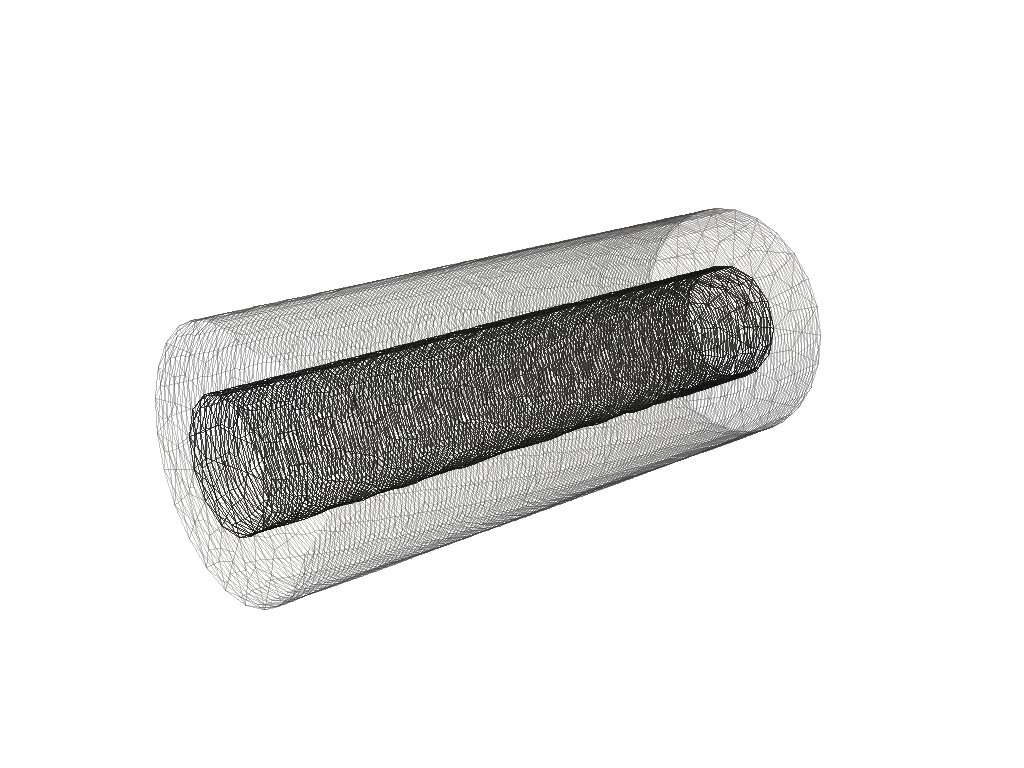

In [12]:
# Static mesh wireframe — visual check right after mesh generation.

viz_xy_scale = 0.25 / epsilon_f

topo, ctypes, geom = dplot.vtk_mesh(mesh, d)
grid = pv.UnstructuredGrid(topo, ctypes, geom)
tags = np.zeros(grid.n_cells, dtype=np.int32)
tags[cell_tags.indices] = cell_tags.values
grid.cell_data['tag'] = tags
geom_sc = geom.copy(); geom_sc[:, :2] *= viz_xy_scale
grid.points = geom_sc

fluid_grid = grid.extract_cells(np.where(grid.cell_data['tag'] == FLUID_FLAG)[0])
solid_grid = grid.extract_cells(np.where(grid.cell_data['tag'] == SOLID_FLAG)[0])

z_stretch = 2.5
for g in [fluid_grid, solid_grid]:
    g.points[:, 2] *= z_stretch

pl = pv.Plotter(notebook=True)
pl.add_mesh(fluid_grid, style='wireframe', color='black', line_width=0.3, opacity=0.5)
pl.add_mesh(solid_grid, style='wireframe', color='gray',  line_width=0.1, opacity=0.2)
pl.view_vector((0, -1, 0), viewup=(1, 0, 0))
pl.camera.azimuth   = -40
pl.camera.elevation =  20
pl.show()


### Subdomain locator functions

These identify geometric subsets (used for Dirichlet BCs and diagnostics) in the cylindrical coordinate frame where $r = \sqrt{x^2+y^2}$.

In [13]:
def solid_interior_locator(x):
    r   = np.sqrt(x[0]**2 + x[1]**2)
    a_z = a_of_z_np(x[2])
    b_z = b_of_z_np(x[2])
    return (    (r > a_z + d_tol)
              & (r < b_z - d_tol)
              & (x[2] > d_tol)
              & (x[2] < L - d_tol))

def fluid_interior_locator(x):
    r   = np.sqrt(x[0]**2 + x[1]**2)
    a_z = a_of_z_np(x[2])
    return (    (r < a_z - d_tol)
              & (x[2] > d_tol)
              & (x[2] < L - d_tol))

def fs_interface_locator(x):
    """Fluid-solid interface r = a(z). Use 5*d_tol to catch curved-surface nodes."""
    r   = np.sqrt(x[0]**2 + x[1]**2)
    a_z = a_of_z_np(x[2])
    return np.abs(r - a_z) < 5.0 * d_tol

def solid_p_locator(x):
    """Solid domain (strictly r > a(z)); used to pin p=0 in the solid.
    Interface nodes (r ≈ a(z)) are deliberately excluded so their pressure
    is determined by the fluid equations."""
    r   = np.sqrt(x[0]**2 + x[1]**2)
    a_z = a_of_z_np(x[2])
    return r > a_z + d_tol

In [14]:
# Integration measures with appropriate quadrature degree.
qd = 5
dx = Measure("dx", domain=mesh, subdomain_data=cell_tags,
             metadata={"quadrature_degree": qd})
ds = Measure("ds", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})
dS = Measure("dS", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})

dX   = dx(SOLID_FLAG)   # solid volume integral
dy   = dx               # full-domain volume integral (fluid + solid)
ds_y = ds               # reference-config surface integral

In [59]:
# Sanity check: verify identified boundary surfaces.
print("==================================== DIAGNOSTICS ====================================")
print("Checking identification of boundary surfaces ...")
A_in  = assemble_scalar(form(Constant(mesh, 1.0) * ds(INFLOW)))
A_out = assemble_scalar(form(Constant(mesh, 1.0) * ds(OUTFLOW)))
A_if  = assemble_scalar(form(Constant(mesh, 1.0) * dS(INTERFACE)))
# Expected inner interface area (tapered frustum): π (a0 + aL) s,  s = sqrt(L^2 + (aL-a0)^2)
s_if = np.sqrt(L**2 + (aL - a0)**2)
A_if_expect = np.pi * (a0 + aL) * s_if
A_in_expect = np.pi * a0**2
A_out_expect = np.pi * aL**2
rel_in = abs(A_in - A_in_expect) / max(abs(A_in_expect), 1e-16)
rel_out = abs(A_out - A_out_expect) / max(abs(A_out_expect), 1e-16)
rel_if = abs(A_if - A_if_expect) / max(abs(A_if_expect), 1e-16)
print(f"|Γ_in|  = {A_in:.6e}  ;  expected area = π a0² = {A_in_expect:.6e}  ; " \
      f"rel.err = {100*rel_in:.2f}%")
print(f"|Γ_out| = {A_out:.6e}  ;  expected area = π aL² = {A_out_expect:.6e}  ; " \
      f"rel.err = {100*rel_out:.2f}%")
print(f"|Γ_fs|  = {A_if:.6e}  ;  expected area =  ...  = {A_if_expect:.6e}  ; " \
      f"rel.err = {100*rel_if:.2f}%")

print()
tol_area = 0.02  # 2% relative tolerance
if (rel_in > tol_area) or (rel_out > tol_area) or (rel_if > tol_area):
    print("WARNING: |Γ| mismatch exceeds 2% tolerance on at least one surface; " \
          "refine the mesh!")
else:
    print("Area checks passed: all |Γ| are within 2% tolerance.")
print("=====================================================================================")

==================================== DIAGNOSTICS ====================================
Checking identification of boundary surfaces ...
|Γ_in|  = 3.020701e-04  ;  expected area = π a0² = 3.141593e-04  ; rel.err = 3.85%
|Γ_out| = 3.020701e-04  ;  expected area = π aL² = 3.141593e-04  ; rel.err = 3.85%
|Γ_fs|  = 4.668712e-02  ;  expected area =  ...  = 4.712389e-02  ; rel.err = 0.93%



# Variational problem definitions

## Elements, function spaces, and variables

In [16]:
# Mixed function space: (velocity, pressure, displacement) = (P2^3, P1, P2^3)
# Taylor-Hood pair (P2/P1) for velocity/pressure; P2 for displacement.
cell_name = mesh.topology.cell_name()

Ve  = basix_ufl.element("Lagrange", cell_name, 2, shape=(d,))   # P2 vector (velocity)
Qe  = basix_ufl.element("Lagrange", cell_name, 1)               # P1 scalar (pressure)
Ue  = basix_ufl.element("Lagrange", cell_name, 2, shape=(d,))   # P2 vector (displacement)

Ze = basix_ufl.mixed_element([Ve, Qe, Ue])
Z  = functionspace(mesh, Ze)

z          = Function(Z, name="z")
v, p, u    = split(z)
dv, dp, du = TestFunctions(Z)

print(f"Total DOFs: {z.x.array.size}")

Total DOFs: 277407


## ALE kinematics

Standard ALE notation:
- $\mathbf{y} =$ reference (mesh) coordinate,
- $\mathbf{x} = \mathbf{y} + \mathbf{u}$ is the spatial (deformed) coordinate,
- $\mathbf{F}_m = \nabla_\mathbf{y} \mathbf{x} = \mathbf{I} + \nabla_\mathbf{y} \mathbf{u}$ is the ALE mesh deformation gradient.

All built-in operators (`grad`, `div`, …) act w.r.t. $\mathbf{y}$; spatial derivatives must be mapped through $\mathbf{F}_m$.

In [17]:
grad_y   = grad
y        = SpatialCoordinate(mesh)
x        = y + u
det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f), inv(grad_y(x)))

def div_x(f):
    return tr(grad_x(f))

def div_x_tens(f):
    i, j = indices(2)   # abstract indices; valid for any spatial dimension
    return as_tensor(grad_x(f)[i, j, j], (i,))

## Boundary conditions (simulation)

**Velocity:**
- No-slip on rigid outer wall (RIGID_OUTER_WALL_3D_TAG): $\mathbf{v}=\mathbf{0}$.
- No velocity on solid end caps (SOLID_INLET/OUTLET_RING_3D_TAG): $\mathbf{v}=\mathbf{0}$.
- No velocity in solid interior (geometrically): $\mathbf{v}=\mathbf{0}$.
- Kinematic coupling at interface (topologically): $\mathbf{v}=\mathbf{0}$ (steady ALE).
- FLOW mode: prescribed power-law Hagen&ndash;Poiseuille profile at FLUID_INLET_3D_TAG.

**Pressure:** pin $p=0$ in the solid domain (excluding the interface).

**Displacement:** clamp $\mathbf{u}=\mathbf{0}$ on all external faces: outer wall, solid rings, fluid inlet, fluid outlet.

In [18]:
fdim = mesh.topology.dim - 1
mesh.topology.create_connectivity(fdim, mesh.topology.dim)

# Collapse mixed subspaces for Function-valued BCs:
Z0, _ = Z.sub(0).collapse()   # velocity
Z1, _ = Z.sub(1).collapse()   # pressure
Z2, _ = Z.sub(2).collapse()   # displacement

zero_vel_fn  = Function(Z0)
zero_disp_fn = Function(Z2)
zero_p_fn    = Function(Z1)


# ---- Velocity BCs: solid/rigid-wall surfaces (Pattern B: topological) ----
def vel_bc_facets(facets):
    """Zero-velocity Dirichlet BC on an array of facet entity indices."""
    dofs = locate_dofs_topological((Z.sub(0), Z0), fdim, facets)
    return dirichletbc(zero_vel_fn, dofs, Z.sub(0))

# Rigid outer wall (solid): v = 0
ns_facets = facet_tags.find(RIGID_OUTER_WALL_3D_TAG)
# Solid inlet/outlet end caps: v = 0
s_facets  = np.concatenate([facet_tags.find(SOLID_INLET_RING_3D_TAG),
                             facet_tags.find(SOLID_OUTLET_RING_3D_TAG)])

bc_v_ns_walls = vel_bc_facets(ns_facets)  # outer rigid wall
bc_v_s_walls  = vel_bc_facets(s_facets)   # solid end caps

# Solid interior: v = 0 (geometric locator — cylindrical geometry; same strategy as 2D).
# Excludes boundary nodes (outer wall, end caps, interface) which are covered by
# the topological facet BCs above and bc_v_iface below.
dofs_v_solid_int = locate_dofs_geometrical((Z.sub(0), Z0), solid_interior_locator)
bc_v_solid_int   = dirichletbc(zero_vel_fn, dofs_v_solid_int, Z.sub(0))

# Interface kinematic BC: v = 0 (topological — more reliable than geometric on curved surface)
dofs_v_iface = locate_dofs_topological((Z.sub(0), Z0),
                                        fdim, facet_tags.find(INTERFACE))
bc_v_iface   = dirichletbc(zero_vel_fn, dofs_v_iface, Z.sub(0))

bcs_f = [bc_v_ns_walls, bc_v_s_walls, bc_v_solid_int, bc_v_iface]


# ---- Inlet BC: FLOW → tube Hagen-Poiseuille; PRESSURE → Neumann ----
if FLOW_OR_PRESSURE == "FLOW":
    v_in_fn = Function(Z0, name="v_in")

    def v_in_array(x, Q_now):
        """Power-law Hagen-Poiseuille tube profile; velocity is in z-direction (index 2)."""
        vals  = np.zeros((3, x.shape[1]), dtype=dolfinx.default_scalar_type)
        r     = np.sqrt(x[0]**2 + x[1]**2)
        mask  = r < a0 + d_tol     # fluid region at z=0 face
        r_m   = r[mask]
        v_max = Q_now * (3*n_val + 1) / (2.0 * np.pi * n_val * a0**2)
        vals[2, mask] = v_max * (1.0 - (r_m / a0)**((n_val + 1) / n_val))
        return vals

    def update_v_in(Q_now):
        v_in_fn.interpolate(lambda x: v_in_array(x, Q_now))

    update_v_in(q_amp_val)

    dofs_v_in = locate_dofs_topological((Z.sub(0), Z0),
                                         fdim, facet_tags.find(INFLOW))
    bc_in  = dirichletbc(v_in_fn, dofs_v_in, Z.sub(0))
    bcs_in = [bc_in]

elif FLOW_OR_PRESSURE == "PRESSURE":
    # Pressure applied as Neumann (traction) in the variational form.
    bcs_in = []


# ---- Pressure BC: pin p=0 in solid (excluding interface nodes) ----
dofs_p_solid = locate_dofs_geometrical((Z.sub(1), Z1), solid_p_locator)
bc_p_solid   = dirichletbc(zero_p_fn, dofs_p_solid, Z.sub(1))
bcs_p        = [bc_p_solid]


# ---- Displacement BCs: u=0 on all external surfaces ----
def disp_bc_facets(facets):
    dofs = locate_dofs_topological((Z.sub(2), Z2), fdim, facets)
    return dirichletbc(zero_disp_fn, dofs, Z.sub(2))

bc_u_outer = disp_bc_facets(facet_tags.find(RIGID_OUTER_WALL_3D_TAG))
bc_u_sin   = disp_bc_facets(facet_tags.find(SOLID_INLET_RING_3D_TAG))
bc_u_sout  = disp_bc_facets(facet_tags.find(SOLID_OUTLET_RING_3D_TAG))
bc_u_fin   = disp_bc_facets(facet_tags.find(FLUID_INLET_3D_TAG))
bc_u_fout  = disp_bc_facets(facet_tags.find(FLUID_OUTLET_3D_TAG))
bcs_s      = [bc_u_outer, bc_u_sin, bc_u_sout, bc_u_fin, bc_u_fout]

In [19]:
# chi_f: indicator for fluid subdomain (1 in fluid, 0 in solid).
V0 = functionspace(mesh, basix_ufl.element("DG", cell_name, 0))
chi_f = Function(V0, name="chi_f")
fluid_dofs_dg = np.concatenate([V0.dofmap.cell_dofs(c)
                                 for c in cell_tags.find(FLUID_FLAG)])
chi_f.x.array[fluid_dofs_dg] = 1.0
chi_f.x.scatter_forward()
# chi_s = 1 - chi_f  (UFL expression: 1 in solid, 0 in fluid)

In [ ]:
# Report on '+'/'-' interface orientation, which is handled dynamically:
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
f2c          = mesh.topology.connectivity(mesh.topology.dim - 1, mesh.topology.dim)
fluid_cells  = set(cell_tags.find(FLUID_FLAG).tolist())
iface_facets = facet_tags.find(INTERFACE)

n_plus_fluid = n_minus_fluid = 0
for fac in iface_facets:
    cells  = f2c.links(int(fac))
    c_plus = int(min(cells))
    n_plus_fluid  += int(c_plus in fluid_cells)
    n_minus_fluid += int(c_plus not in fluid_cells)

n_total = len(iface_facets)
print("========================= INFO ONLY =========================")
print("Interface '+'/'-' fluid-side distribution:")
print(f"  fluid on '-': {n_minus_fluid}/{n_total}  ({100*n_minus_fluid/n_total:.1f}%)")
print(f"  fluid on '+': {n_plus_fluid}/{n_total}  ({100*n_plus_fluid/n_total:.1f}%)")
print("(chi_f will handle traction & mixed orientation correctly)")
print("=============================================================")

========================= INFO ONLY =========================
Interface '+'/'-' fluid-side distribution:
  fluid on '-': 2268/3742  (60.6%)
  fluid on '+': 1474/3742  (39.4%)
(chi_f will handle traction & mixed orientation correctly)


## Monolithic residual

### Solid and mesh (elasticity) subproblems

The neo-Hookean model is the **full 3D** isochoric-volumetric split:
$$
    \mathbf{S} = \mu_s J^{-2/3}\left(\mathbf{I} - \tfrac{1}{3}I_1 \mathbf{C}^{-1}\right)
               + K(J-1)J\,\mathbf{C}^{-1},
    \qquad
    I_1 = \mathrm{tr}(\mathbf{C}),
$$
with $\mathbf{C} = \mathbf{F}^T\mathbf{F}$ (3×3 right Cauchy&ndash;Green tensor). **No plane-strain $+1$ correction is added** to $I_1$.

In [ ]:
F_s   = I + grad_y(u)          # deformation gradient (= ALE mesh deformation gradient)
F_m   = F_s
Eps_s = 0.5*(F_s.T*F_s - I)    # Green-Lagrange strain tensor

if ELASTICITY_MODEL == "STVK":
    S_solid = K*tr(Eps_s)*I + 2.0*mu_s*(Eps_s - tr(Eps_s)*I/3.0)

elif ELASTICITY_MODEL == "NEOH":
    J_s  = det(F_s)
    C_s  = F_s.T * F_s
    # Full 3D neo-Hookean: I1 = tr(C_s) in 3D.
    I1   = tr(C_s)
    Cinv = inv(C_s)

    # Isochoric contribution:
    S_iso   = mu_s * J_s**(-2.0/3.0) * (I - (1.0/3.0)*I1*Cinv)
    # Volumetric contribution: U = (K/2)*(J-1)^2
    S_vol   = K * (J_s - 1.0) * J_s * Cinv
    S_solid = S_iso + S_vol

else:
    raise ValueError(f"Unknown ELASTICITY_MODEL: {ELASTICITY_MODEL!r}")

# Mesh pseudo-elastic stiffness (increases as det(F_m) decreases to protect elements):
m_jac_stiff_pow    = Constant(mesh, 3.0)
mesh_stiffness_factor = Constant(mesh, 10.0 * alpha_thick)
K_m    = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
mu_m   = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
S_mesh = K_m*tr(Eps_s)*I + 2.0*mu_m*(Eps_s - tr(Eps_s)*I/3.0)

if mesh_approach == "SPLIT":
    res_s = (inner(F_s*S_solid, grad_y(du)) * dx(SOLID_FLAG)
             + inner(F_s*S_mesh,  grad_y(du)) * dx(FLUID_FLAG))

elif mesh_approach == "BLENDED":
    chi_s   = 1.0 - chi_f
    S_blend = chi_s*S_solid + chi_f*S_mesh
    res_s   = inner(F_s*S_blend, grad_y(du)) * dx

else:
    raise ValueError(f"Unknown mesh_approach: {mesh_approach!r}")

### Fluid subproblem

Steady incompressible Navier&ndash;Stokes with Carreau viscosity in ALE coordinates. The formulation is dimension-agnostic &mdash; all operators use the 3D mesh automatically.

In [21]:
# Steady ALE: mesh velocity = 0.
vhat_m = Constant(mesh, np.zeros(d))

def gamma_dot(v_):
    return sqrt(2.0*inner(sym(grad_x(v_)), sym(grad_x(v_))) + DOLFIN_EPS)

def mu_eff(v_):
    return (eta_f_inf + (eta_f_0 - eta_f_inf)
            * (1.0 + (lam_r*gamma_dot(v_))**2.0)**((n - 1.0)/2.0))

sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

v_adv = v - vhat_m
DvDt  = dot(grad_x(v), v_adv)

resGal_f = (rho_f*dot(DvDt, dv)
            + inner(sigma_f, grad_x(dv))
            + dp*div_x(v)) * det_dxdy * dx(FLUID_FLAG)

# Deformed-mesh metric tensor for SUPG/PSPG stabilization:
J_cov    = Jacobian(mesh)
dxi_dy_m = inv(J_cov)
dxi_dx_m = dxi_dy_m * inv(grad_y(x))
G        = dxi_dx_m.T * dxi_dx_m

resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

Cinv_stab = Constant(mesh, 1.0)
tau_M = 1.0 / sqrt(inner(rho_f*v_adv, G*(rho_f*v_adv))
                   + Cinv_stab*(eta_f_0**2)*inner(G, G) + DOLFIN_EPS)
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv), v_adv)
                  + grad_x(dp)) * det_dxdy * dx(FLUID_FLAG)

tau_C     = 1.0 / (tr(G)*tau_M + DOLFIN_EPS)
resLSIC_f = tau_C*div_x(v)*div_x(dv) * det_dxdy * dx(FLUID_FLAG)

# Backflow-stable Neumann term on outflow:
dsx_dsy_n_x  = det_dxdy * inv(F_m.T) * n_y
v_adv_minus  = min_value(dot(v_adv, dsx_dsy_n_x), Constant(mesh, 0.0))
gm           = Constant(mesh, 1.0)
resOutflow_f = -gm * dot(rho_f*v_adv_minus*dv, v) * ds(OUTFLOW)

res_f = resGal_f
if SUPG:
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f

if FLOW_OR_PRESSURE == "PRESSURE":
    # Inlet pressure as consistent Neumann traction:
    res_f += -inner(det_dxdy * inv(F_m.T) * (-p_amp * n_y), dv) * ds(INFLOW)

### Fluid–solid coupling

The traction balance on $\Gamma_{fs}$ is enforced through the fluid 1st Piola–Kirchhoff traction acting on the solid test function. The `chi_f`-based selection handles mixed `+`/`-` interface orientations produced by `occ.fragment()`.

In [22]:
F_fluid_p   = F_m('+')
F_fluid_m   = F_m('-')
J_fluid_p   = det(F_fluid_p)
J_fluid_m   = det(F_fluid_m)
sigma_fpl_p = sigma_f('+')
sigma_fpl_m = sigma_f('-')

P_fluid_p = J_fluid_p * sigma_fpl_p * inv(F_fluid_p.T)
P_fluid_m = J_fluid_m * sigma_fpl_m * inv(F_fluid_m.T)

t_ref = chi_f('+') * (P_fluid_p * n_y('+')) + chi_f('-') * (P_fluid_m * n_y('-'))
du_s  = (1.0 - chi_f('+')) * du('+') + (1.0 - chi_f('-')) * du('-')

res_if = inner(t_ref, du_s) * dS(INTERFACE)

### Total residual and boundary condition list

In [24]:
if FLUID_MODE_ONLY:
    tdim = mesh.topology.dim
    num_cells_local = mesh.topology.index_map(tdim).size_local
    cells_local = np.arange(num_cells_local, dtype=np.int32)
    h_local = float(np.min(mesh.h(tdim, cells_local)))
    h_min   = mesh.comm.allreduce(h_local, op=MPI.MIN)

    alpha_u0 = Constant(mesh, 1e3 * eta_f_0_val / h_min)
    alpha_u1 = Constant(mesh, 1e2 * eta_f_0_val)

    res  = (res_f
            + alpha_u0 * inner(u, du) * dx
            + alpha_u1 * h_min**2 * inner(grad_y(u), grad_y(du)) * dx)
    bcs  = bcs_f + bcs_in + bcs_p
else:
    res  = res_f + res_s + res_if
    bcs  = bcs_f + bcs_in + bcs_p + bcs_s

Dres = derivative(res, z)

# Nonlinear solver for the monolithic problem

In [25]:
problem = NonlinearProblem(
    res, z,
    petsc_options_prefix="steady3d_",
    bcs=bcs,
    J=Dres,
    jit_options={"cffi_extra_compile_args": ["-O3", "-march=native"]},
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_8":  77,
        "mat_mumps_icntl_24": 1,
        "mat_mumps_icntl_13": 1,
        "mat_mumps_cntl_1":   0.001,
        "pc_factor_shift_amount": 1e-10,
        "pc_factor_shift_type": "NONZERO",
        "snes_type": "newtonls",
        "snes_linesearch_type": "l2",
        "snes_linesearch_max_it":  10,
        "snes_max_linear_solve_fail": 10,
        "snes_rtol": 1e-6,
        "snes_atol": 1e-8,
        "snes_max_it": 50,
        "snes_error_if_not_converged": 0,
        "ksp_error_if_not_converged":  0,
        "snes_converged_reason": "",
        "snes_monitor": "",
    },
)

Solve the monolithic system. 🤞

In [26]:
v_out = Function(Z0, name="v")
p_out = Function(Z1, name="p")
u_out = Function(Z2, name="u")
vfile = VTXWriter(mesh.comm, DataFolder+"velocity.bp",     [v_out], engine="BP4")
pfile = VTXWriter(mesh.comm, DataFolder+"pressure.bp",     [p_out], engine="BP4")
ufile = VTXWriter(mesh.comm, DataFolder+"displacement.bp", [u_out], engine="BP4")

print("="*60, flush=True)
print(f"Starting nonlinear solve with {z.x.array.size} DOFs.", flush=True)
print("="*60, flush=True)

error = False
for index, load_factor in enumerate(load_factors):
    print(f"\n{'-'*60}", flush=True)
    print(f"Trying load factor = {load_factor} ...", flush=True)
    print(f"{'-'*60}", flush=True)

    if FLOW_OR_PRESSURE == "FLOW":
        update_v_in(load_factor * q_amp_val)
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_amp.value = load_factor * p_amp_val

    z_last_working = z.x.array.copy()

    try:
        problem.solve()
        reason    = problem.solver.getConvergedReason()
        converged = reason > 0
        print(f"  Converged: {converged}  (reason={reason})", flush=True)

        if not converged:
            print("\n" + "="*60, flush=True)
            print("  ⚠️  WARNING: SNES DID NOT CONVERGE  ⚠️", flush=True)
            print("="*60 + "\n", flush=True)
            error = True
    except RuntimeError as e:
        print("\n" + "="*60, flush=True)
        print(f"Caught RuntimeError: {e}", flush=True)
        print(f"  ⚠️ Failed on load factor: {load_factor}", flush=True)
        print("="*60 + "\n", flush=True)
        z.x.array[:] = z_last_working
        z.x.scatter_forward()
        error = True
        break

    v_out.interpolate(z.sub(0))
    p_out.interpolate(z.sub(1))
    u_out.interpolate(z.sub(2))
    vfile.write(float(load_factor))
    pfile.write(float(load_factor))
    ufile.write(float(load_factor))

vfile.close()
pfile.close()
ufile.close()

if not error:
    print(f"{'='*60}", flush=True)
    print("  >>>SUCCESS<<< Full load reached! 🎉 🎉 🎉", flush=True)
    print(f"{'='*60}", flush=True)

Starting nonlinear solve with 277407 DOFs.

------------------------------------------------------------
Trying load factor = 1.0 ...
------------------------------------------------------------
  0 SNES Function norm 3.663378469534e-02
  1 SNES Function norm 2.299493279037e-02
  2 SNES Function norm 1.259245395882e-02
  3 SNES Function norm 2.541405624414e-03
  4 SNES Function norm 7.294634952807e-04
  5 SNES Function norm 7.412407283120e-05
  6 SNES Function norm 1.123891305529e-06
  7 SNES Function norm 1.037063107944e-09
  Nonlinear steady3d_ solve converged due to CONVERGED_FNORM_ABS iterations 7
  Converged: True  (reason=2)
  >>>SUCCESS<<< Full load reached! 🎉 🎉 🎉


### Diagnostics

In [55]:
# ── Mesh Jacobian ──────────────────────────────────────────────────────────────
J_dg   = Function(V0)
J_expr = Expression(det(F_m), V0.element.interpolation_points)
J_dg.interpolate(J_expr)
J_vals = J_dg.x.array

# ── Mass conservation on fluid boundaries ──────────────────────────────────────
q_in    = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)  * ds(INFLOW)))
q_out   = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)  * ds(OUTFLOW)))
q_walls = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)  * ds(RIGID_OUTER_WALL_3D_TAG)))
q_FS    = assemble_scalar(form(dot(v_out('+'), n_y('+')) * dS(INTERFACE)))
sum_q   = float(q_in + q_out + q_walls + q_FS)

# ── Divergence diagnostic ──────────────────────────────────────────────────────
mass_residual = assemble_scalar(form(det_dxdy * div_x(v) * dx(FLUID_FLAG)))

# ── Kinematic mismatch on Γ_fs ─────────────────────────────────────────────────
slip = np.sqrt(assemble_scalar(form(inner(v_out('+'), v_out('+')) * dS(INTERFACE))))

# ── Pressure at sample points along the tube axis (x=0, y=0) ──────────────────
z_test     = np.array([0.0, L/3, L/2, 2*L/3, L])
pts        = np.column_stack([np.zeros_like(z_test),
                               np.zeros_like(z_test),
                               z_test])
tree       = bb_tree(mesh, mesh.topology.dim)
cell_cands = compute_collisions_points(tree, pts)
coll_cells = compute_colliding_cells(mesh, cell_cands, pts)
valid_mask  = np.array([len(coll_cells.links(i)) > 0 for i in range(len(z_test))])
valid_pts   = pts[valid_mask]
valid_cells = np.array([coll_cells.links(i)[0]
                        for i in range(len(z_test)) if len(coll_cells.links(i)) > 0])
p_computed  = np.full(len(z_test), float('nan'))
if valid_pts.shape[0] > 0:
    p_computed[valid_mask] = p_out.eval(valid_pts, valid_cells).flatten()
p_theory_thick = [p_sh_thick_py(zi) for zi in z_test]

# ── Peak interface radial displacement (sampled at angle θ=0, i.e. y=0) ───────
_z_if    = np.linspace(L/20, L*19/20, 20)
_a_z_if  = a_of_z_np(_z_if)
_pts_if  = np.column_stack([_a_z_if, np.zeros(20), _z_if])  # (a(z), 0, z)
_cells_if = [compute_colliding_cells(
                 mesh, compute_collisions_points(tree, _pts_if), _pts_if
             ).links(i)[0] for i in range(20)]
_u_if     = u_out.eval(_pts_if, _cells_if)   # shape (20, 3): [ux, uy, uz] per point
_ur_if    = _u_if[:, 0]                       # radial displacement at θ=0: u_r = u_x
a_max_sim = a0 + float(_ur_if.max())
z_amax    = float(_z_if[np.argmax(_ur_if)])

# Soft-hydraulics prediction from thick constrained cylinder model
a_sh_thick_pred = a0 * (1 + alpha_thick)
a_err = 100*(a_sh_thick_pred-a_max_sim)/a_max_sim

q_err = (q_sh_thick - np.abs(q_in))/np.abs(q_in)*100

# ── Print ──────────────────────────────────────────────────────────────────────
print("======================== DIAGNOSTICS ========================")
print("Mesh deformation diagnostics:")
print(f"det(F) min: {J_vals.min():.6f}  |  det(F) max: {J_vals.max():.6f}")
print(f"Inverted elements: {sum(J_vals < 0)}  |  Near-inverted (J<0.3): {sum(J_vals < 0.3)}")
print()
print("Deformation predictions test:")
print(f"a_max from theory  = {a_sh_thick_pred:.6g}  at z=0 (constrained cyl)")
print(f"a_max from sim     = {a_max_sim:.6g}  at z={z_amax:.4g} (error = {a_err:.2f}%)")
print()
print("Flow rate predictions test:")
print(f"rigid     = {q_rigid:.6e}")
print(f"sh theory = {q_sh_thick:.6e}")
print(f"sim in    = {q_in:.6e}  (expect < 0, error = {q_err:.1f}%)")
print(f"sim out   =  {q_out:.6e}  (expect > 0)")
print()
print("Flow rate consistency diagnostics for the simulation:")
print(f"q_walls        = {q_walls:6e}  (expect ≈ 0, rigid outer wall)")
print(f"q_FS           = {q_FS:.6e}  (expect ≈ 0, no-penetration)")
print(f"Σ q            = {sum_q:.6e}  (expect: < 1e-6)")
print(f"∫ div(v) dΩ_f  = {mass_residual:.6e}  (target: < 1e-8)")
print()
print(f"FS kinematic mismatch ||v||_Γfs = {float(slip):.6e}  (expect ≈ 0)")

if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble_scalar(form(
        inner(v_out - v_in_fn, v_out - v_in_fn) * ds(INFLOW)))
    print(f"Inlet velocity mismatch ||v-v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

print()
print("Pressure (p/p_c) predictions along tube axis:")
for label, i in [("z=0",    0), ("z=L/3",  1),
                  ("z=L/2",  2), ("z=2L/3", 3)]:
    s, t_thk = p_computed[i], p_theory_thick[i]
    err_thk  = 100.0 * abs(s - t_thk)  / abs(t_thk) if abs(t_thk)  > 1e-30 else float('nan')
    print(f"  {label:6s}: sim = {s/float(p_c):8.6f},  "
          f"theory = {t_thk/float(p_c):8.6f} (error = {err_thk:.1f}%)")
print("=============================================================")

======================== DIAGNOSTICS ========================
Mesh deformation diagnostics:
det(F) min: 0.925767  |  det(F) max: 1.244332
Inverted elements: 0  |  Near-inverted (J<0.3): 0

Deformation predictions test:
a_max from theory  = 0.0110714  at z=0 (constrained cyl)
a_max from sim     = 0.0109718  at z=0.0375 (error = 0.91%)

Flow rate predictions test:
rigid     = 2.761473e-04
sh theory = 3.743307e-04
sim in    = -3.017637e-04  (expect < 0, error = 24.0%)
sim out   =  3.017637e-04  (expect > 0)

Flow rate consistency diagnostics for the simulation:
q_walls        = 0.000000e+00  (expect ≈ 0, rigid outer wall)
q_FS           = 0.000000e+00  (expect ≈ 0, no-penetration)
Σ q            = -2.710505e-19  (expect: < 1e-6)
∫ div(v) dΩ_f  = 4.211838e-20  (target: < 1e-8)

FS kinematic mismatch ||v||_Γfs = 0.000000e+00  (expect ≈ 0)

Pressure (p/p_c) predictions along tube axis:
  z=0   : sim = 1.003922,  theory = 1.000000 (error = 0.4%)
  z=L/3 : sim = 0.689655,  theory = 0.689447 (e

# Visualization and post-processing

## Axial pressure distribution

Pressure is cross-sectionally averaged over the fluid area at each axial location and compared with rigid-tube and soft-hydraulics theories.

Compliance #, α_thick = 0.10714  (thick constrained cylinder)
Fluid sample count per section: min=414,max=425, mean=420.6


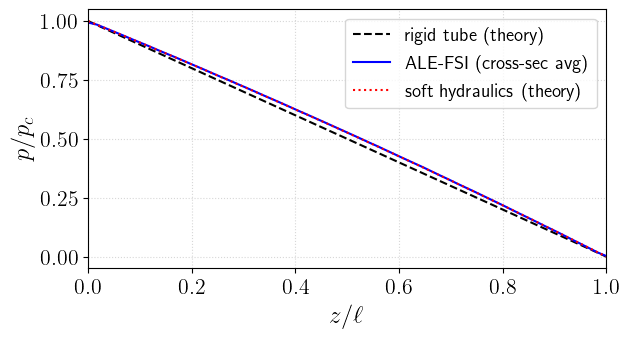

In [41]:
num_z_samples = 60
z_vals = np.linspace(0.0, L, num_z_samples)

# Cross-sectional averaging in each z-plane (fluid points only).
fluid_cells = set(cell_tags.find(FLUID_FLAG).tolist())
num_xy_samples = 49
r_box = 1.02 * max(float(b0_outer), float(bL_outer))
xy = np.linspace(-r_box, r_box, num_xy_samples)
xx, yy = np.meshgrid(xy, xy, indexing='xy')
xy_pts = np.column_stack([xx.ravel(), yy.ravel()])

def pressure_avg_at_z(zi):
    pts = np.column_stack([xy_pts, np.full(xy_pts.shape[0], float(zi))])
    cands = compute_collisions_points(tree, pts)
    colls = compute_colliding_cells(mesh, cands, pts)

    ids, cells = [], []
    for i in range(pts.shape[0]):
        links = colls.links(i)
        c = next((int(k) for k in links if int(k) in fluid_cells), None)
        if c is not None:
            ids.append(i)
            cells.append(c)

    if not ids:
        return np.nan, 0

    ids = np.asarray(ids, dtype=np.int32)
    vals = p_out.eval(pts[ids], np.asarray(cells, dtype=np.int32)).flatten()
    return float(np.mean(vals)), int(ids.size)

avg_pairs = [pressure_avg_at_z(zi) for zi in z_vals]
p_avg = np.array([p for p, _ in avg_pairs], dtype=float)
n_kept = np.array([n for _, n in avg_pairs], dtype=np.int32)

pressure_rigid_vals     = np.array([p_rigid_py(zi)     for zi in z_vals])
pressure_sh_thick_vals  = np.array([p_sh_thick_py(zi)  for zi in z_vals])

fig, ax = plt.subplots(tight_layout=True)
ax.plot(z_vals/L, pressure_rigid_vals/float(p_c),
        label='rigid tube (theory)', linestyle='dashed', color='black')
ax.plot(z_vals/L, p_avg/float(p_c),
        label='ALE-FSI (cross-sec avg)', color='blue')
ax.plot(z_vals/L, pressure_sh_thick_vals/float(p_c),
        label=r'soft hydraulics (theory)',
        linestyle='dotted', color='red')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend()
ax.set_xlim(0, 1)
ax.set_box_aspect(1/2)
print(f"Compliance #, α_thick = {alpha_thick:.5f}  (thick constrained cylinder)")
print(f"Fluid sample count per section: min={n_kept.min()}," \
      f"max={n_kept.max()}, mean={n_kept.mean():.1f}")
plt.show()

## Fluid–solid interface: radial displacement and pressure

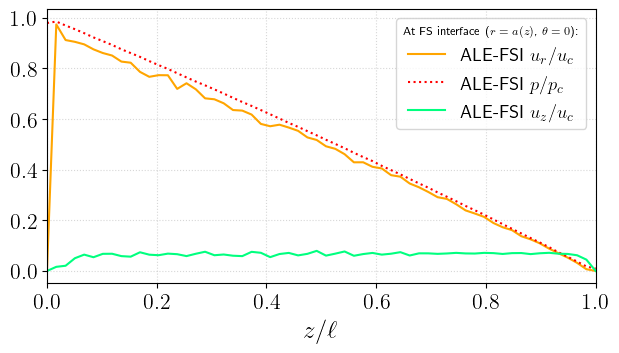

In [47]:
# Sample along the interface at angle θ=0 (x=a(z), y=0, z=z):
z_if    = np.linspace(0.0, L, num_z_samples)
a_z_if  = a_of_z_np(z_if)
pts_if  = np.column_stack([a_z_if, np.zeros(num_z_samples), z_if])

cands_if = compute_collisions_points(tree, pts_if)
colls_if = compute_colliding_cells(mesh, cands_if, pts_if)
valid_if = np.array([len(colls_if.links(i)) > 0 for i in range(num_z_samples)])

u_r_if  = np.full(num_z_samples, float('nan'))
u_z_if  = np.full(num_z_samples, float('nan'))
p_if    = np.full(num_z_samples, float('nan'))

valid_ip = pts_if[valid_if]
valid_ic = np.array([colls_if.links(i)[0] 
                     for i in range(num_z_samples) if len(colls_if.links(i)) > 0])
if valid_ip.shape[0] > 0:
    u_vals_if = u_out.eval(valid_ip, valid_ic)    # shape (N_valid, 3)
    u_r_if[valid_if] = u_vals_if[:, 0]            # radial displacement (u_x at θ=0)
    u_z_if[valid_if] = u_vals_if[:, 2]            # axial displacement
    p_if[valid_if]   = p_out.eval(valid_ip, valid_ic).flatten()

fig, ax = plt.subplots(tight_layout=True)
ax.plot(z_if/L, u_r_if/(alpha_thick*a0),
        label=r'ALE-FSI $u_r/u_c$', color='orange')
ax.plot(z_if/L, p_if/float(p_c),
        label=r'ALE-FSI $p/p_c$ ', color='red', linestyle='dotted')
ax.plot(z_if/L, u_z_if/(alpha_thick*a0),
        label=r'ALE-FSI $u_z/u_c$ ', color='springgreen')
ax.set_xlabel(r'$z/\ell$')
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(title="At FS interface ($r=a(z)$, $\\theta=0$):", title_fontsize='small')
ax.set_xlim(0, 1)
ax.set_box_aspect(1/2)
plt.show()

## Field preparation for contour plots

Interpolate pressure/velocity/displacement to a nodal plotting space and build shared limits for the 2D contour plots below.

In [ ]:
# Shared PyVista helper utilities for 3D rendering cells.

pv.set_jupyter_backend('static')
pv.global_theme.background = 'white'
pv.global_theme.font.color = 'black'

def robust_limits(arr, lo=0.02, hi=0.98):
    vals = np.asarray(arr)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0.0, 1.0)
    vmin = float(np.quantile(vals, lo))
    vmax = float(np.quantile(vals, hi))
    if vmax <= vmin:
        vmax = vmin + 1e-12
    return (vmin, vmax)

In [44]:
# Build scalar P1 plotting space for interpolating solution fields to mesh nodes.
V_plot = functionspace(mesh, ("Lagrange", 1))

# Pressure on P1.
p_plot = Function(V_plot)
p_plot.interpolate(p_out)

# Velocity magnitude on P1.
vmag_plot = Function(V_plot)
vmag_plot.interpolate(Expression(sqrt(dot(v_out, v_out)),
                                  V_plot.element.interpolation_points))

# Displacement magnitude on P1.
umag_plot = Function(V_plot)
umag_plot.interpolate(Expression(sqrt(dot(u_out, u_out)),
                                  V_plot.element.interpolation_points))

# Build pyvista grid and attach fields to points (used by 2D slice plotting below).
topology_p, cell_types_p, geometry_p = dplot.vtk_mesh(V_plot)
grid_fields = pv.UnstructuredGrid(topology_p, cell_types_p, geometry_p)
grid_fields.point_data['p/p_c']   = p_plot.x.array.real / float(p_c)
grid_fields.point_data['|v|/v_c'] = vmag_plot.x.array.real / float(v_c)
grid_fields.point_data['|u|/u_c'] = umag_plot.x.array.real / float(alpha_thick * a0)

# Tag fluid/solid cells.
domain_tag_p = np.zeros(grid_fields.n_cells, dtype=np.int32)
domain_tag_p[cell_tags.indices] = cell_tags.values
grid_fields.cell_data['domain_tag'] = domain_tag_p

# Visualization-only radial scaling to avoid ultra-flat plots in slender geometry.
viz_xy_scale = float(np.clip(0.15 * (L / a0), 6.0, 14.0))
grid_fields_viz = grid_fields.copy(deep=True)
pts_viz = grid_fields_viz.points.copy()
pts_viz[:, 0] *= viz_xy_scale
pts_viz[:, 1] *= viz_xy_scale
grid_fields_viz.points = pts_viz

# Quarter-cut geometry and camera preset reused in the final 3D rendering cell.
grid_quarter = grid_fields_viz.clip(normal=(1.0, 0.0, 0.0), 
                                    origin=(0.0, 0.0, 0.0), invert=False)
grid_quarter = grid_quarter.clip(normal=(0.0, 1.0, 0.0), 
                                 origin=(0.0, 0.0, 0.0), invert=False)
camera_pos = [(-0.78 * L, 0.92 * viz_xy_scale * b0_outer, 0.62 * L),
              (0.08 * L, 0.02 * viz_xy_scale * b0_outer, 0.50 * L),
              (0.0, 1.0, 0.0)]

clim_p = robust_limits(grid_fields.point_data['p/p_c'])
clim_v = robust_limits(grid_fields.point_data['|v|/v_c'])
clim_u = robust_limits(grid_fields.point_data['|u|/u_c'])

print("Contour-plot fields prepared.")
print(f"  visualization radial scaling (x,y): x{viz_xy_scale:.2f}")
print(f"  p/p_c range:   [{grid_fields.point_data['p/p_c'].min():.3f}," \
      f"{grid_fields.point_data['p/p_c'].max():.3f}] | robust={clim_p}")
print(f"  |v|/v_c range: [{grid_fields.point_data['|v|/v_c'].min():.3f}," \
      f"{grid_fields.point_data['|v|/v_c'].max():.3f}] | robust={clim_v}")
print(f"  |u|/u_c range: [{grid_fields.point_data['|u|/u_c'].min():.3f}," \
      f"{grid_fields.point_data['|u|/u_c'].max():.3f}] | robust={clim_u}")

Contour-plot fields prepared.
  visualization radial scaling (x,y): x11.25
  p/p_c range:   [-0.005,1.004] | robust=(0.0, 0.9548765219788192)
  |v|/v_c range: [0.000,1.896] | robust=(0.0, 1.6292657045295362)
  |u|/u_c range: [0.000,0.996] | robust=(0.0, 0.8693108680436014)


## Pressure contours

Using meridional slice angle: theta = 90.0 deg


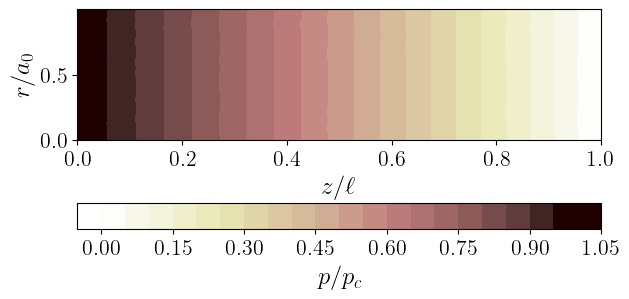

In [32]:
# 2D pressure view on a meridional plane at angle theta: (z horizontal, r vertical).
theta_deg = 90.0  # choose plane angle in degrees
theta = np.deg2rad(theta_deg)
print(f"Using meridional slice angle: theta = {theta_deg:.1f} deg")

# Use unscaled geometry for physically meaningful (r, z) coordinates.
fluid_cells = np.where(grid_fields.cell_data['domain_tag'] == FLUID_FLAG)[0]
fluid_grid = grid_fields.extract_cells(fluid_cells)

# Plane through axis with azimuth theta.
n_plane = np.array([-np.sin(theta), np.cos(theta), 0.0])
slice_theta = fluid_grid.slice(normal=n_plane, origin=(0.0, 0.0, 0.0))

pts = slice_theta.points
if pts.shape[0] < 3:
    raise RuntimeError("Too few points in theta-slice. Try a different theta or mesh resolution.")

# Radial coordinate along chosen azimuth direction; keep the r >= 0 half-plane with tolerance.
e_r = np.array([np.cos(theta), np.sin(theta)])
r_signed = pts[:, 0] * e_r[0] + pts[:, 1] * e_r[1]
r_tol = 1e-6 * max(1.0, float(np.max(np.abs(r_signed))))
half_mask = r_signed >= -r_tol

r_plot = np.maximum(np.asarray(r_signed[half_mask], dtype=float), 0.0)
z_plot = np.asarray(pts[half_mask, 2], dtype=float)
p_plot_2d = np.asarray(slice_theta.point_data['p/p_c'][half_mask], dtype=float)

# Scale coordinates: z by ell, r by a0
z_scaled = z_plot / L
r_scaled = r_plot / a0

# Simple/clean triangulated plot.
triang = mtri.Triangulation(z_scaled, r_scaled)

fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, p_plot_2d, levels=20, cmap='pink_r', vmin=clim_p[0], vmax=clim_p[1])
fig.colorbar(contour, ax=ax, label=r'$p/p_c$', orientation='horizontal')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$r/a_0$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

Using meridional slice angle: theta = 90.0 deg


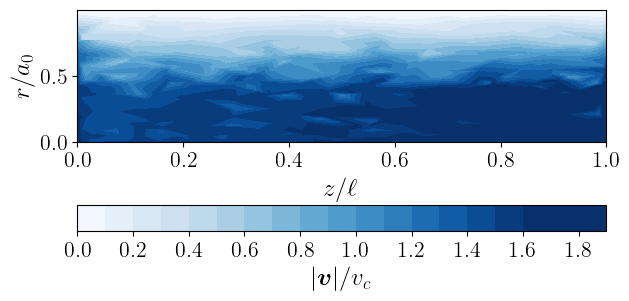

In [33]:
# 2D velocity-magnitude view on a meridional plane at angle theta: (z horizontal, r vertical).
theta_deg = 90.0  # choose plane angle in degrees
theta = np.deg2rad(theta_deg)
print(f"Using meridional slice angle: theta = {theta_deg:.1f} deg")

# Use unscaled geometry for physically meaningful (r, z) coordinates.
fluid_cells = np.where(grid_fields.cell_data['domain_tag'] == FLUID_FLAG)[0]
fluid_grid = grid_fields.extract_cells(fluid_cells)

# Plane through axis with azimuth theta.
n_plane = np.array([-np.sin(theta), np.cos(theta), 0.0])
slice_theta = fluid_grid.slice(normal=n_plane, origin=(0.0, 0.0, 0.0))

pts = slice_theta.points
if pts.shape[0] < 3:
    raise RuntimeError("Too few points in theta-slice. Try a different theta or mesh resolution.")

# Radial coordinate along chosen azimuth direction; keep the r >= 0 half-plane with tolerance.
e_r = np.array([np.cos(theta), np.sin(theta)])
r_signed = pts[:, 0] * e_r[0] + pts[:, 1] * e_r[1]
r_tol = 1e-6 * max(1.0, float(np.max(np.abs(r_signed))))
half_mask = r_signed >= -r_tol

r_plot = np.maximum(np.asarray(r_signed[half_mask], dtype=float), 0.0)
z_plot = np.asarray(pts[half_mask, 2], dtype=float)
v_plot_2d = np.asarray(slice_theta.point_data['|v|/v_c'][half_mask], dtype=float)

# Scale coordinates: z by ell, r by a0
z_scaled = z_plot / L
r_scaled = r_plot / a0

# Ensure field values are non-negative (magnitude should never be negative)
v_plot_2d = np.abs(v_plot_2d)

fig, ax = plt.subplots(tight_layout=True)
triang = mtri.Triangulation(z_scaled, r_scaled)
contour = ax.tricontourf(triang, v_plot_2d, levels=20, cmap='Blues', vmin=clim_v[0], vmax=clim_v[1])

cb = fig.colorbar(contour, ax=ax, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{v}|/v_c$')
else:
    cb.set_label(r'$|\vec{v}|/v_c$')
    
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$r/a_0$')

ax.set_aspect(1 / 4)

plt.show()

## Displacement magnitude contours

Using meridional slice angle: theta_deg = 90.0 deg


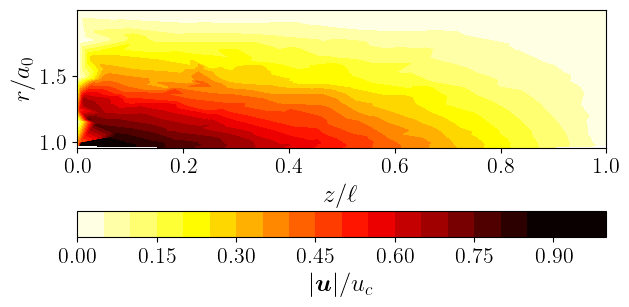

In [ ]:
# 2D displacement-magnitude view on a meridional plane 
# at angle theta: (z horizontal, r vertical).
theta_deg = 90.0  # choose plane angle in degrees
theta = np.deg2rad(theta_deg)
print(f"Using meridional slice angle: theta_deg = {theta_deg:.1f} deg")

# Use unscaled geometry for physically meaningful (r, z) coordinates.
solid_cells = np.where(grid_fields.cell_data['domain_tag'] == SOLID_FLAG)[0]
solid_grid = grid_fields.extract_cells(solid_cells)

# Plane through axis with azimuth theta.
n_plane = np.array([-np.sin(theta), np.cos(theta), 0.0])
slice_theta = solid_grid.slice(normal=n_plane, origin=(0.0, 0.0, 0.0))

pts = slice_theta.points
if pts.shape[0] < 3:
    raise RuntimeError("Too few points in theta-slice. " \
                       "Try a different theta or mesh resolution.")

# Radial coordinate along chosen azimuth direction; 
# keep the r >= 0 half-plane with tolerance.
e_r = np.array([np.cos(theta), np.sin(theta)])
r_signed = pts[:, 0] * e_r[0] + pts[:, 1] * e_r[1]
r_tol = 1e-6 * max(1.0, float(np.max(np.abs(r_signed))))
half_mask = r_signed >= -r_tol

r_plot = np.maximum(np.asarray(r_signed[half_mask], dtype=float), 0.0)
z_plot = np.asarray(pts[half_mask, 2], dtype=float)
u_plot_2d = np.asarray(slice_theta.point_data['|u|/u_c'][half_mask], dtype=float)

# Scale coordinates: z by ell, r by a0
z_scaled = z_plot / L
r_scaled = r_plot / a0

# Ensure field values are non-negative (magnitude should never be negative)
u_plot_2d = np.abs(u_plot_2d)

fig, ax = plt.subplots(tight_layout=True)
triang = mtri.Triangulation(z_scaled, r_scaled)
contour = ax.tricontourf(triang, u_plot_2d, 
                         levels=20, cmap='hot_r', vmin=clim_u[0], vmax=clim_u[1])

cb = fig.colorbar(contour, ax=ax, orientation='horizontal')

if params['text.usetex']:
    cb.set_label(r'$|\bm{u}|/u_c$')
else:
    cb.set_label(r'$|\vec{u}|/u_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$r/a_0$')

ax.set_aspect(1 / 4)

plt.show()

## Cross-sectional contours at $z_\mathrm{slice}$

Using planar cross-section: z = 3.750e-01 or z/L = 0.500


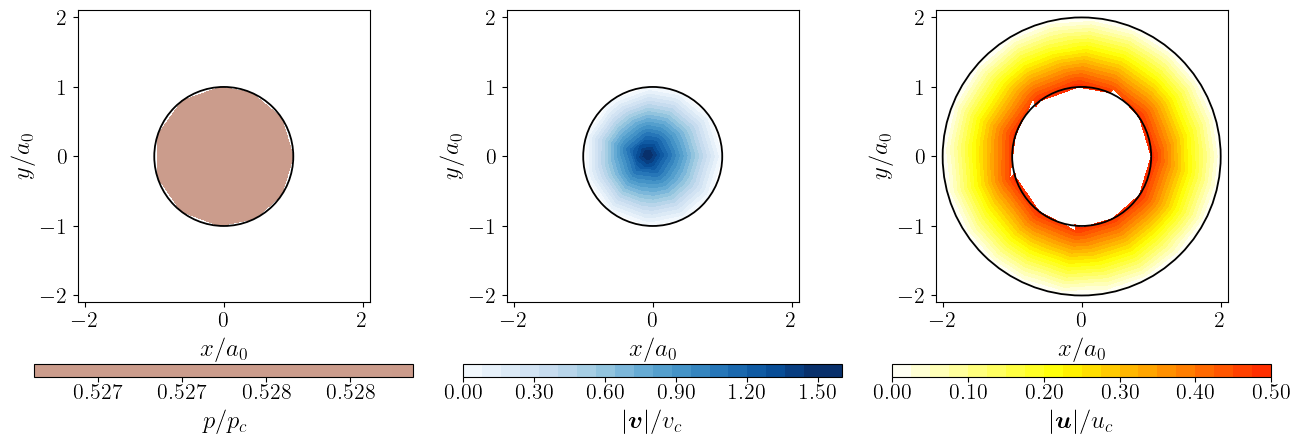

In [ ]:
# Planar cross-section at z = L/2 with styling matched to meridional plots.
from matplotlib.patches import Circle
from matplotlib.ticker import MaxNLocator, FuncFormatter

z_slice = L / 2.0
print(f"Using planar cross-section: z = {z_slice:.3e} or z/L = {z_slice/L:.3f}")

# Slice fluid and solid separately so each panel uses the correct domain data.
fluid_cells = np.where(grid_fields.cell_data['domain_tag'] == FLUID_FLAG)[0]
solid_cells = np.where(grid_fields.cell_data['domain_tag'] == SOLID_FLAG)[0]

fluid_grid = grid_fields.extract_cells(fluid_cells)
solid_grid = grid_fields.extract_cells(solid_cells)

slice_mid_fluid = fluid_grid.slice(normal=(0.0, 0.0, 1.0), origin=(0.0, 0.0, z_slice))
slice_mid_solid = solid_grid.slice(normal=(0.0, 0.0, 1.0), origin=(0.0, 0.0, z_slice))

pts_f = slice_mid_fluid.points
pts_s = slice_mid_solid.points

if pts_f.shape[0] < 3 or pts_s.shape[0] < 3:
    raise RuntimeError("Too few points in z slice. " \
                       "Check mesh resolution or slice location.")

# Normalize in-plane coordinates by a0 for consistent nondimensional presentation.
x_f = np.asarray(pts_f[:, 0], dtype=float) / a0
y_f = np.asarray(pts_f[:, 1], dtype=float) / a0
x_s = np.asarray(pts_s[:, 0], dtype=float) / a0
y_s = np.asarray(pts_s[:, 1], dtype=float) / a0

p_slice = np.asarray(slice_mid_fluid.point_data['p/p_c'], dtype=float)
v_slice = np.abs(np.asarray(slice_mid_fluid.point_data['|v|/v_c'], dtype=float))
u_slice = np.abs(np.asarray(slice_mid_solid.point_data['|u|/u_c'], dtype=float))

tri_f = mtri.Triangulation(x_f, y_f)
tri_s = mtri.Triangulation(x_s, y_s)

# Force displacement panel to show only annular solid region (outside fluid core).
# Use the actual deformed interface radius from the fluid slice (captures both taper and FSI deformation).
r_fluid_nd = float(np.max(np.sqrt(x_f**2 + y_f**2)))
triangles_s = tri_s.triangles
x_cent_s = np.mean(x_s[triangles_s], axis=1)
y_cent_s = np.mean(y_s[triangles_s], axis=1)
mask_inside_fluid = x_cent_s**2 + y_cent_s**2 < (r_fluid_nd + 1e-6)**2
tri_s.set_mask(mask_inside_fluid)

# Shared limits for visual consistency across all three panels.
r_outer_nd = float(np.max(np.sqrt(x_s**2 + y_s**2)))
xy_lim = 1.05 * r_outer_nd

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6), tight_layout=False)
fig.subplots_adjust(wspace=0.26, bottom=0.24)

def style_cbar(cbar, label, ndigits):
    cbar.set_label(label)
    cbar.locator = MaxNLocator(nbins=6)
    cbar.formatter = FuncFormatter(lambda x, pos: rf"${x:.{ndigits}f}$")
    cbar.update_ticks()
    cbar.ax.tick_params(pad=2)

cf_p = axes[0].tricontourf(tri_f, p_slice, 
                           levels=20, cmap='pink_r', 
                           vmin=clim_p[0], vmax=clim_p[1])
cbar_p = fig.colorbar(cf_p, ax=axes[0], 
                      orientation='horizontal', 
                      pad=0.16, fraction=0.08, aspect=30)
style_cbar(cbar_p, r'$p/p_c$', 3)

cf_v = axes[1].tricontourf(tri_f, v_slice, 
                           levels=20, cmap='Blues', 
                           vmin=clim_v[0], vmax=clim_v[1])
cbar_v = fig.colorbar(cf_v, ax=axes[1], 
                      orientation='horizontal', 
                      pad=0.16, fraction=0.08, aspect=30)
if params['text.usetex']:
    style_cbar(cbar_v, r'$|\bm{v}|/v_c$', 2)
else:
    style_cbar(cbar_v, r'$|\vec{v}|/v_c$', 2)

cf_u = axes[2].tricontourf(tri_s, u_slice, 
                           levels=20, cmap='hot_r', 
                           vmin=clim_u[0], vmax=clim_u[1])
cbar_u = fig.colorbar(cf_u, ax=axes[2], 
                      orientation='horizontal', pad=0.16, 
                      fraction=0.08, aspect=30)
if params['text.usetex']:
    style_cbar(cbar_u, r'$|\bm{u}|/u_c$', 2)
else:
    style_cbar(cbar_u, r'$|\vec{u}|/u_c$', 2)

for ax in axes:
    ax.add_patch(Circle((0.0, 0.0), r_fluid_nd, 
                        fill=False, edgecolor='black', linewidth=1.3, zorder=5))
    ax.set_xlim(-xy_lim, xy_lim)
    ax.set_ylim(-xy_lim, xy_lim)
    ax.set_xlabel(r'$x/a_0$')
    ax.set_ylabel(r'$y/a_0$')
    ax.set_aspect('equal')

# Outer cylinder wall on displacement panel only.
axes[2].add_patch(Circle((0.0, 0.0), r_outer_nd, 
                         fill=False, edgecolor='black', linewidth=1.3, zorder=5))

plt.show()

## 3D visualizations

In [ ]:
# PyVista scalar view: velocity (fluid) + displacement (solid) on deformed geometry.
ux_plot = Function(V_plot)
uy_plot = Function(V_plot)
uz_plot = Function(V_plot)
ux_plot.interpolate(Expression(u_out[0], V_plot.element.interpolation_points))
uy_plot.interpolate(Expression(u_out[1], V_plot.element.interpolation_points))
uz_plot.interpolate(Expression(u_out[2], V_plot.element.interpolation_points))

geom_def = geometry_p.copy()
geom_def[:, 0] += ux_plot.x.array.real
geom_def[:, 1] += uy_plot.x.array.real
geom_def[:, 2] += uz_plot.x.array.real

# Apply same visualization-only radial scaling for readability.
geom_def[:, 0] *= viz_xy_scale
geom_def[:, 1] *= viz_xy_scale

grid_def = pv.UnstructuredGrid(topology_p, cell_types_p, geom_def)
grid_def.point_data['p/p_c']     = p_plot.x.array.real / float(p_c)
grid_def.point_data['|v|/v_c']   = vmag_plot.x.array.real / float(v_c)
grid_def.point_data['|u|/u_c']   = umag_plot.x.array.real / float(alpha_thick * a0)
grid_def.cell_data['domain_tag'] = domain_tag_p

clip_def = grid_def.clip(normal=(1.0, 0.0, 0.0), origin=(0.0, 0.0, 0.0), invert=False)
clip_def = clip_def.clip(normal=(0.0, 1.0, 0.0), origin=(0.0, 0.0, 0.0), invert=False)
fluid_def = clip_def.extract_cells(np.where(clip_def.cell_data['domain_tag'] == FLUID_FLAG)[0])
solid_def = clip_def.extract_cells(np.where(clip_def.cell_data['domain_tag'] == SOLID_FLAG)[0])

pl = pv.Plotter(notebook=True, window_size=(1220, 620))
pl.add_text(f'Deformation and velocity fields, x-y scaled x{viz_xy_scale:.1f}', font_size=10)
pl.add_mesh(fluid_def, scalars='|v|/v_c', clim=clim_v, cmap='Blues',
            show_edges=False, smooth_shading=True, opacity=0.90,
            scalar_bar_args={'title': '|v|/v_c', 'vertical': True,
                             'position_x': 0.85, 'position_y': 0.56,
                             'width': 0.06, 'height': 0.35})
pl.add_mesh(solid_def, scalars='|u|/u_c', clim=clim_u, cmap='hot_r',
            show_edges=False, smooth_shading=True, opacity=0.50,
            scalar_bar_args={'title': '|u|/u_c', 'vertical': True,
                             'position_x': 0.85, 'position_y': 0.10,
                             'width': 0.06, 'height': 0.35})
pl.add_mesh(clip_def.outline(), color='black', line_width=1.0)
pl.camera_position = camera_pos
pl.reset_camera()
pl.camera.zoom(1.05)
pl.show_grid(xtitle='x (scaled)', ytitle='y (scaled)', ztitle='z')
pl.show()